# Demo

This notebook demonstrates how you can use `lazycogs` to lazily load massive arrays of Level 2 data from STAC metadata with cloud-optimized geotiff assets.

In [1]:
from pathlib import Path

import rustac
from pyproj import Transformer

import lazycogs

Define the area of interest with a CRS and a bounding box.

In [2]:
# define the AOI in/ a projection that is suitable for your analysis
dst_crs = "epsg:5070"
dst_bbox = (-700_000, 2_220_000, 600_000, 2_930_000)

# transform to epsg:4326 for STAC search
transformer = Transformer.from_crs(dst_crs, "epsg:4326", always_xy=True)
bbox_4326 = transformer.transform_bounds(*dst_bbox)

Query a STAC API and cache the result to a local stac-geoparquet file using `rustac`. This file will be used by the `lazycogs` backend to determine which COGs are required for which array operations.

This example generates an archive of Sentinel 2 Level 2A items for the summer months of 2025 for an area that covers a large part of Minnesota, USA.

In [3]:
items_parquet = "/tmp/midwest_summer_2025_items.parquet"

if not Path(items_parquet).exists():
    await rustac.search_to(
        items_parquet,
        href="https://earth-search.aws.element84.com/v1",
        collections=["sentinel-2-c1-l2a"],
        datetime="2025-06-01/2025-09-30",
        bbox=bbox_4326,
        limit=100,
    )

Use the stac-geoparquet file to infer the object storage backend for these items (uses first item). Add `skip_signature=True` because these assets are in a public bucket.

In [4]:
store = lazycogs.store_for(items_parquet, skip_signature=True)

Open a 100% lazy `DataArray` representation of the assets referenced in the stac-geoparquet file for your specified CRS and bounding box and resolution. Provide the `store` we created above.

In [5]:
da = lazycogs.open(
    items_parquet,
    crs=dst_crs,
    bbox=dst_bbox,
    resolution=100,
    time_period="P1D",
    bands=["red", "green", "blue"],
    dtype="int16",
    store=store,
)

da

<xarray.DataArray (band: 3, time: 121, y: 7100, x: 13000)> Size: 67GB
[33504900000 values with dtype=int16]
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 968B 2025-06-01 2025-06-02 ... 2025-09-30
  * y        (y) float64 57kB 2.22e+06 2.22e+06 2.22e+06 ... 2.93e+06 2.93e+06
  * x        (x) float64 104kB -7e+05 -6.998e+05 -6.998e+05 ... 5.998e+05 6e+05
Attributes:
    _stac_backend:      MultiBandStacBackendArray(bands=['red', 'green', 'blu...
    _stac_time_coords:  2025-06-01 … 2025-09-30 (n=121)

Get all of the values from June for a single point. Add `chunk(time=1)` to parallelize across time coordinates.

In [6]:
%%time
(
    da.sel(x=299965, y=2653947, method="nearest")
    .sel(time=slice("2025-06-01", "2025-06-30"))
    .chunk(time=1)
    .compute()
)

CPU times: user 2.6 s, sys: 1.12 s, total: 3.72 s
Wall time: 5.51 s


<xarray.DataArray (band: 3, time: 30)> Size: 180B
array([[    0,  2578,     0,  2688,     0, 10193,  2548,     0, 11786,
            0,     0,  8685,     0,  8705,     0,     0,  3066,     0,
        11911,     0,     0,  8338,     0,  2598,     0,  8146, 11202,
            0,  2503,     0],
       [    0,  2482,     0,  2521,     0, 10286,  2439,     0, 12660,
            0,     0,  8963,     0,  8460,     0,     0,  3109,     0,
        12683,     0,     0,  8437,     0,  2477,     0,  8041, 11309,
            0,  2480,     0],
       [    0,  2326,     0,  2307,     0, 10744,  2210,     0, 14304,
            0,     0,  9378,     0,  8434,     0,     0,  2949,     0,
        14094,     0,     0,  8874,     0,  2227,     0,  8012, 11754,
            0,  2258,     0]], dtype=int16)
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 240B 2025-06-01 2025-06-02 ... 2025-06-30
    y        float64 8B 2.654e+06
    x        float64 8B 3e+05
Attributes:
    _stac_backend:      MultiBandStacBackendArray(bands=['red', 'green', 'blu...
    _stac_time_coords:  2025-06-01 … 2025-09-30 (n=121)

Select a spatial subset

In [7]:
subset = da.sel(
    x=slice(100_000, 400_000),
    y=slice(2_600_000, 2_800_000),
)
subset

<xarray.DataArray (band: 3, time: 121, y: 2000, x: 3000)> Size: 4GB
[2178000000 values with dtype=int16]
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 968B 2025-06-01 2025-06-02 ... 2025-09-30
  * y        (y) float64 16kB 2.6e+06 2.6e+06 2.6e+06 ... 2.8e+06 2.8e+06
  * x        (x) float64 24kB 1e+05 1.002e+05 1.002e+05 ... 3.998e+05 4e+05
Attributes:
    _stac_backend:      MultiBandStacBackendArray(bands=['red', 'green', 'blu...
    _stac_time_coords:  2025-06-01 … 2025-09-30 (n=121)

Extract the values for a single point

In [8]:
%%time
subset.isel(time=1, x=0, y=0).compute()

CPU times: user 147 ms, sys: 70.8 ms, total: 218 ms
Wall time: 1.68 s


<xarray.DataArray (band: 3)> Size: 6B
array([1775, 1938, 1705], dtype=int16)
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
    time     datetime64[s] 8B 2025-06-02
    y        float64 8B 2.6e+06
    x        float64 8B 1e+05
Attributes:
    _stac_backend:      MultiBandStacBackendArray(bands=['red', 'green', 'blu...
    _stac_time_coords:  2025-06-01 … 2025-09-30 (n=121)

Use the `stac_cog.explain()` accessor to learn about the underlying assets that will need to be accessed for a particular query.

In [9]:
plan = subset.isel(time=slice(1, 4)).lazycogs.explain(fetch_headers=True)
print(plan.summary())

=== ExplainPlan ===
Parquet:    /tmp/midwest_summer_2025_items.parquet
CRS:        epsg:5070  |  Resolution: 100.0 units/px  |  Grid: 3000 x 2000 px
Bands (3):  red, green, blue
Time steps: 3 (2025-06-02 - 2025-06-04)
Chunks:     3000 x 2000 px -> 1x1 spatial tiles

Total chunk reads:     9 (3 band(s) x 3 time step(s) x 1 spatial tile(s))
Total COG reads:       57
Chunks with 0 COGs:       3 (33.3%)
Chunks with 1 COG:        0 (0.0%)
Chunks with 2+ COGs:      6 (66.7%)
Max COGs per chunk:    12
Overview levels:       ovr 2: 57
Avg read window:       1092 x 955 px
(Use .to_dataframe() for per-item overview and window details.)


Plot an RGB image of the subset area

Estimated peak in-flight memory for bands=['red', 'green', 'blue'] is ~824 MB (12 concurrent reads × 3 bands × 3000x2000 px). Lower max_concurrent_reads or add spatial chunks to reduce memory use.


CPU times: user 22 s, sys: 1.85 s, total: 23.8 s
Wall time: 18.5 s


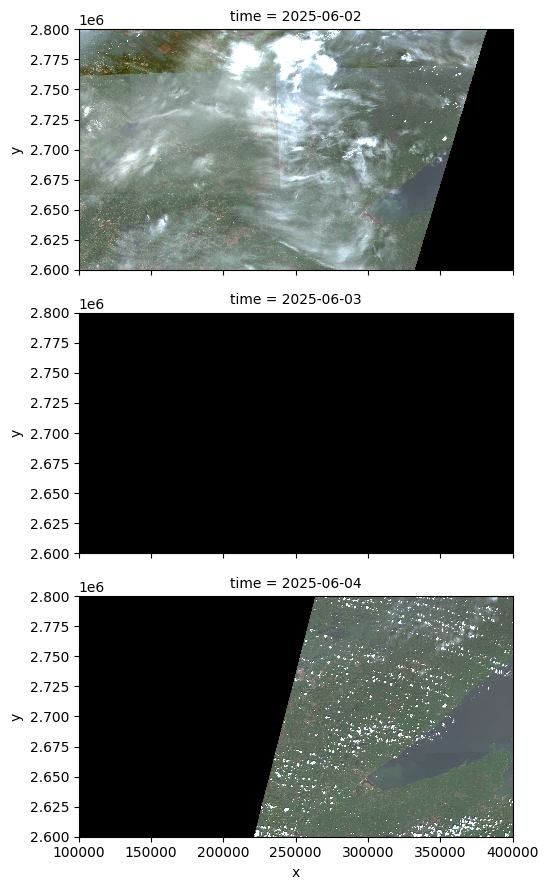

In [10]:
%%time
(
    subset.isel(time=slice(1, 4)).plot.imshow(
        rgb="band",
        row="time",
        vmin=0,
        vmax=4000,
        aspect=subset.shape[3] / subset.shape[2],
    )
)

In [11]:
# define the AOI in/ a projection that is suitable for your analysis
dst_crs = "epsg:3310"
dst_bbox = (-444000, -609000, 681000, 500000)

# transform to epsg:4326 for STAC search
transformer = Transformer.from_crs(dst_crs, "epsg:4326", always_xy=True)
bbox_4326 = transformer.transform_bounds(*dst_bbox)

ca_items_parquet = "/tmp/ca_spring_2025_items.parquet"

if not Path(ca_items_parquet).exists():
    await rustac.search_to(
        ca_items_parquet,
        href="https://earth-search.aws.element84.com/v1",
        collections=["sentinel-2-c1-l2a"],
        datetime="2025-03-01/2025-06-30",
        bbox=bbox_4326,
        limit=100,
    )

Open an array with 300 meter resolution with records flattened by month, only processing records with <50% cloud cover. This will result in an array with one time coordinate per month, the least cloudy images will be used first when fetching actual data.

In [12]:
store = lazycogs.store_for(ca_items_parquet, skip_signature=True)

ca_monthly = await lazycogs.open_async(
    ca_items_parquet,
    crs=dst_crs,
    bbox=dst_bbox,
    resolution=300,
    time_period="P1M",
    bands=["red", "green", "blue"],
    dtype="int16",
    filter="eo:cloud_cover < 50",
    sortby="eo:cloud_cover",
    store=store,
)

ca_monthly

<xarray.DataArray (band: 3, time: 4, y: 3697, x: 3750)> Size: 333MB
[166365000 values with dtype=int16]
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 32B 2025-03-01 2025-04-01 ... 2025-06-01
  * y        (y) float64 30kB -6.088e+05 -6.086e+05 ... 4.996e+05 5e+05
  * x        (x) float64 30kB -4.438e+05 -4.436e+05 ... 6.806e+05 6.808e+05
Attributes:
    _stac_backend:      MultiBandStacBackendArray(bands=['red', 'green', 'blu...
    _stac_time_coords:  2025-03-01 … 2025-06-01 (n=4)

In [13]:
ca_may = ca_monthly.chunk(x=512, y=512).sel(time="2025-05-01")
ca_may

<xarray.DataArray (band: 3, y: 3697, x: 3750)> Size: 83MB
dask.array<getitem, shape=(3, 3697, 3750), dtype=int16, chunksize=(3, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * y        (y) float64 30kB -6.088e+05 -6.086e+05 ... 4.996e+05 5e+05
  * x        (x) float64 30kB -4.438e+05 -4.436e+05 ... 6.806e+05 6.808e+05
    time     datetime64[s] 8B 2025-05-01
Attributes:
    _stac_backend:      MultiBandStacBackendArray(bands=['red', 'green', 'blu...
    _stac_time_coords:  2025-03-01 … 2025-06-01 (n=4)

Show the query plan summary including overview and window information. This will open the COG headers for all relevant files so it can take a while.

In [14]:
plan = ca_may.lazycogs.explain(fetch_headers=True)

print(plan.summary())

=== ExplainPlan ===
Parquet:    /tmp/ca_spring_2025_items.parquet
CRS:        epsg:3310  |  Resolution: 300.0 units/px  |  Grid: 3750 x 3697 px
Bands (3):  red, green, blue
Time steps: 1 (2025-05-01)
Chunks:     512 x 512 px -> 8x8 spatial tiles

Total chunk reads:     192 (3 band(s) x 1 time step(s) x 64 spatial tile(s))
Total COG reads:       12909
Chunks with 0 COGs:       6 (3.1%)
Chunks with 1 COG:        3 (1.6%)
Chunks with 2+ COGs:    183 (95.3%)
Max COGs per chunk:    147
Overview levels:       ovr 3: 12909
Avg read window:       412 x 397 px
(Use .to_dataframe() for per-item overview and window details.)


Load the array

In [ ]:
%%time
from dask.diagnostics import ProgressBar

with ProgressBar():
    ca_may.load()

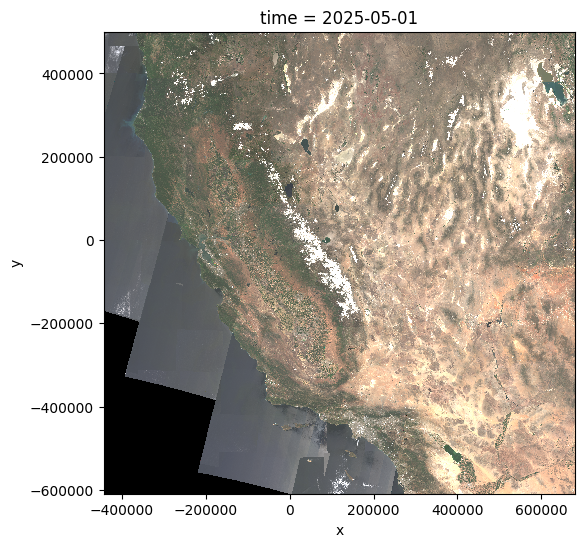

In [16]:
ca_may.plot.imshow(
    rgb="band",
    vmin=0,
    vmax=4000,
    size=6,
    aspect=ca_may.shape[2] / ca_may.shape[1],
)